# A* vs MCTS (Design-based)
This notebook compares A* and MCTS **on Design.py only**.
Data loading is reused from the original test; NewDesign / KMeansSampler pipelines are removed.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import os
import glob
import time
import numpy as np
import matplotlib.pyplot as plt
import operator 
import graphical_sampling as gs
from package_sampling.utils import inclusion_probabilities
from graphical_sampling.design import Design
from graphical_sampling.criteria.var_nht import VarNHT
from graphical_sampling.search.astar import AStar
from graphical_sampling.search.mcts import MCTS
from graphical_sampling.validation.design_validity import (
    check_probability_sum,
    check_fip_consistency,
)


## Load population CSVs (unchanged)

In [2]:
import os
import glob
import numpy as np

DATA_DIR = "populations"
csv_paths = glob.glob(os.path.join(DATA_DIR, "*.csv"))

coords_dict = {}
probs_dict = {}

for fp in csv_paths:
    name = os.path.splitext(os.path.basename(fp))[0]
    try:
        data = np.loadtxt(fp, delimiter=",", skiprows=1)
        coords = data[:, :2]
        probs  = data[:, -1]
    except Exception:
        continue

    parts = name.split("_")
    if len(parts) >= 2:
        coord_name = parts[0]
        prob_name = parts[1]
    else:
        coord_name = parts[0]
        prob_name = 'unequal' 

    coord_name = 'cluster' if coord_name == 'clust' else coord_name
    prob_name  = 'equal' if prob_name == 'eq' else 'unequal'

    coords_dict[coord_name] = coords
    probs_dict.setdefault(coord_name, {})[prob_name] = probs

print("Available populations:", coords_dict.keys())

Available populations: dict_keys(['AggregatedPop1027', 'cluster', 'grid', 'meuse', 'MU284', 'random', 'RegularPop1000', 'swiss'])


## Select dataset

In [33]:
rng = np.random.default_rng()
n = 4
coords = coords_dict['swiss']
base_probs = probs_dict['swiss']['unequal']         
aux = base_probs + rng.random(100)
pi = inclusion_probabilities(aux, n=n)        

initial_design = Design(inclusion = pi, variable = base_probs , permute = False)

## Build initial Design (Design.py)

Initial VarNHT: 9.286797523498535


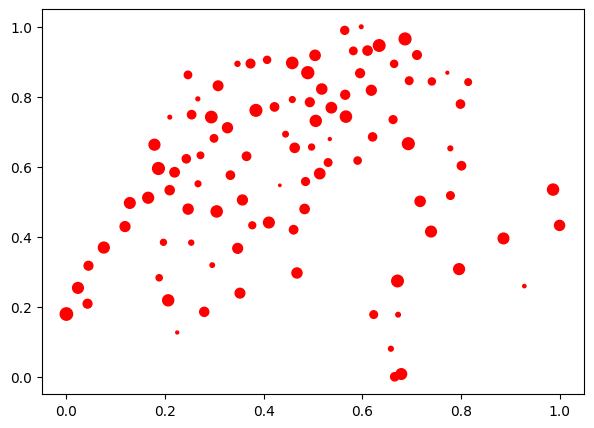

initial_designs_list was made successfully ✅
length of initial_designs_list:  10


In [34]:
criteria = operator.attrgetter('nht_variance')

initial_value = criteria(initial_design)
print("Initial VarNHT:", initial_value)
print(initial_design)

import matplotlib.pyplot as plt
x = coords[:, 0]
y = coords[:, 1]

plt.figure(figsize=(7,5))
plt.scatter(x, y, s=1000*pi, color = 'red')
plt.show()

population_size = 10

initial_designs_list = [initial_design] 

for _ in range(population_size - 1):
    d = Design(inclusion=pi, variable=base_probs, permute=True)
    initial_designs_list.append(d)
    
print("initial_designs_list was made successfully ✅")
print("length of initial_designs_list: ", len(initial_designs_list))

## Run A* (Design-based)

In [35]:
import time

astar = AStar(
    initial_designs=[initial_design],  
    switch_coefficient=0.5,
    random_pull=False
)

t0 = time.perf_counter()


astar.run(
    max_iterations=200,
    num_new_nodes=10,
    max_open_set_size=1000,
    num_changes=(5, 5),  
    top_k=5              
)

elapsed_astar = time.perf_counter() - t0

# چاپ نتایج
print("A* best VarNHT:", astar.best_criteria_value)
print("A* time (s):", round(elapsed_astar, 3))

A* best VarNHT: 7.620619773864746
A* time (s): 0.15


## Run MCTS (Design-based)

In [37]:
import time

# =====================================================
# 1) Run Multi-Start MCTS (High Exploration Mode)
# =====================================================
t0 = time.perf_counter()

if __name__ == "__main__":
    mcts = MCTS(
        initial_designs=initial_designs_list,
        criteria=criteria,
        switch_coefficient= 1.0,  
        base_changes=20,          
        exploration_constant= 0.1 
    )

    best_design_mcts, best_value_mcts = mcts.run(
        max_iterations=100,    
        max_children_per_node=8
    )

elapsed_mcts = time.perf_counter() - t0

print("MCTS best VarNHT:", best_value_mcts)
print("MCTS time (s):", round(elapsed_mcts, 3))
# =====================================================
# 2) Validation — exactly what the professor asked
# =====================================================
print("\n=== VALIDATION: Best MCTS Design ===")

if 'best_design_mcts' in locals():
    target_design = best_design_mcts
elif 'best_design' in locals():
    target_design = best_design
else:
    raise NameError("❌ متغیر دیزاین پیدا نشد! لطفا سلول اجرای MCTS را دوباره اجرا کنید.")

target_probs = probs 

# ---- (A) Sum of probabilities = 1
ok_prob, prob_sum = check_probability_sum(target_design)

print(f"Probability sum: {prob_sum:.10f}")
print(f"Probability sum OK: {ok_prob}")

# ---- (B) FIP reconstruction check
ok_fip, max_diff, _ = check_fip_consistency(
    target_design,
    target_probs,
)

print(f"FIP consistency OK: {ok_fip}")
print(f"Max |FIP - reconstructed|: {max_diff:.10e}")


=== MULTI-START MCTS (Population Size: 10) ===
Best Initial Criteria: 7.1265130043029785
=== RUN STARTED (ADAPTIVE POPULATION MODE) ===

>>> ITER 0 | Depth 1 | Val: 0.00

  >>> STAGNATION (8 iters) -> TELEPORT #1 to Best (7.13)
  ★ BEST: 7.1 -> 7.1 (Type: high)
  ★ BEST: 7.1 -> 6.7 (Type: high)
  ★ BEST: 6.7 -> 6.6 (Type: low)

  >>> STAGNATION (8 iters) -> TELEPORT #2 to Best (6.65)
  ★ BEST: 6.6 -> 6.1 (Type: high)

  >>> STAGNATION (8 iters) -> TELEPORT #3 to Best (6.07)
  ★ BEST: 6.1 -> 6.0 (Type: high)
  ★ BEST: 6.0 -> 5.9 (Type: high)
  ★ BEST: 5.9 -> 5.8 (Type: high)

  >>> STAGNATION (8 iters) -> TELEPORT #4 to Best (5.76)
  ★ BEST: 5.8 -> 5.8 (Type: high)
  ★ BEST: 5.8 -> 5.7 (Type: high)
  ★ BEST: 5.7 -> 5.7 (Type: high)
  ★ BEST: 5.7 -> 5.7 (Type: low)

>>> ITER 20 | Depth 2 | Val: 1.66

  >>> STAGNATION (8 iters) -> TELEPORT #5 to Best (5.65)
  ★ BEST: 5.7 -> 5.7 (Type: high)
  ★ BEST: 5.7 -> 5.6 (Type: high)
  ★ BEST: 5.6 -> 5.6 (Type: low)
  ★ BEST: 5.6 -> 5.6 (Type: low)

## Final comparison

In [38]:
print("========== FINAL COMPARISON ==========")
print("Initial VarNHT :", initial_value)
print("A* VarNHT      :", astar.best_criteria_value)
print("MCTS VarNHT    :", best_value_mcts)


========== FINAL COMPARISON ==========
Initial VarNHT : 9.286797523498535
A* VarNHT      : 7.620619773864746
MCTS VarNHT    : 4.7377729415893555
